(200, 21)
Client                object
State                 object
VisitID#              object
Patient Name          object
DOS                   object
Aging Days             int64
Aging Bucket          object
Submitted Date        object
Insurance Name        object
Status                object
Billed Amount        float64
Balance Amount       float64
Primary/Secondary     object
AR notes              object
Type                  object
Status Code           object
Action Code           object
Assigned To           object
Worked By             object
Worked Date           object
Follow up date        object
dtype: object
Client               0
State                0
VisitID#             0
Patient Name         0
DOS                  0
Aging Days           0
Aging Bucket         0
Submitted Date       0
Insurance Name       0
Status               0
Billed Amount        0
Balance Amount       0
Primary/Secondary    0
AR notes             0
Type                 0
Status Code          0

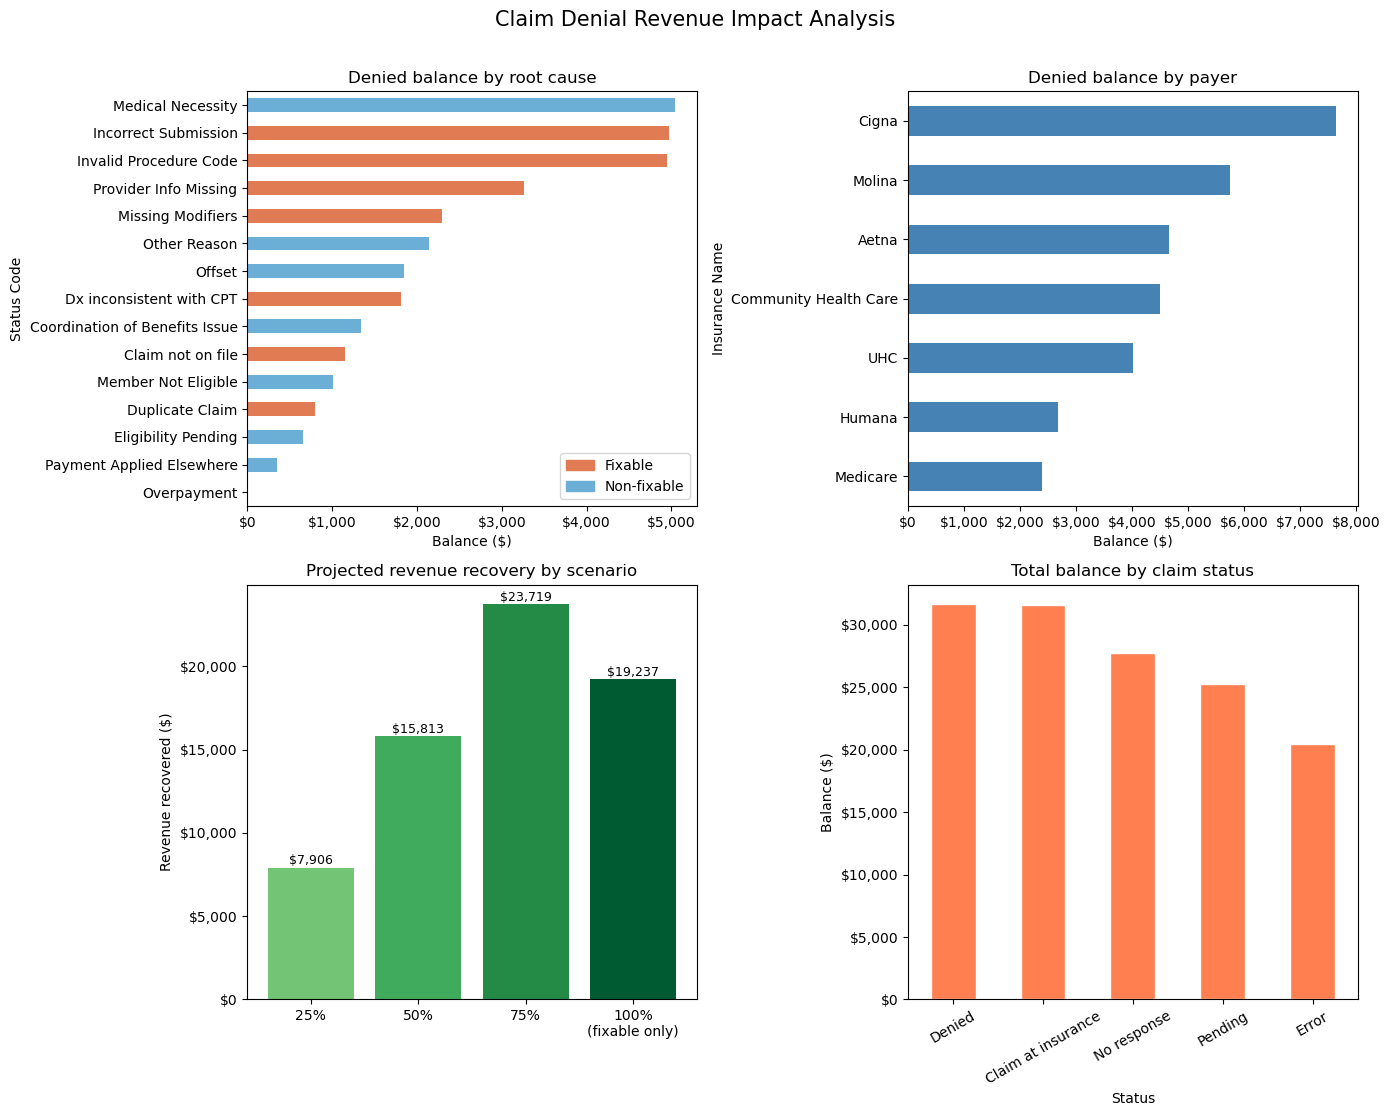

All reports saved to outputs/
src/model.py saved

BUSINESS RECOMMENDATIONS

1. IMMEDIATE ACTION — Coding & submission errors ($13,243 at risk)
   - 'Incorrect Submission', 'Invalid Procedure Code', 'Missing Modifiers',
     and 'Provider Info Missing' account for the largest fixable denial share
   - Assign coding team to review and resubmit within 30 days
   - Consider a pre-submission audit checklist

2. PAYER FOCUS — Cigna & Molina highest denial balances
   - Cigna:  $7,649 denied across 12 claims (highest volume)
   - Molina: $5,743 denied across 9 claims
   - Schedule payer-specific meetings to clarify submission requirements

3. RECOVERY POTENTIAL
   - Fixing just 50% of denials recovers ~$15,812
   - Full recovery of fixable claims could return ~$19,236.64
   - All denied claims are in the 181+ aging bucket — time-sensitive

4. PROCESS IMPROVEMENTS
   - Implement eligibility verification before DOS to reduce
     'Member Not Eligible' and 'Coordination of Benefits' denials
   -

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

###Upload CSV
df = pd.read_csv('C:/Users/blueg/OneDrive/Documents/revenue-lost-claim-denials/Data/Synthetic AR Medical Dataset with Realistic Denial.csv')

###Clean and Standardize Data
#Inspect Shape, dtypes, null values
print(df.shape) 
print(df.dtypes)
print(df.isnull().sum())
print(df.head())

# Strip whitespace from all string columns
df.columns = df.columns.str.strip()
df = df.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)

# Parse dates
df['DOS']            = pd.to_datetime(df['DOS'])
df['Submitted Date'] = pd.to_datetime(df['Submitted Date'])
df['Worked Date']    = pd.to_datetime(df['Worked Date'])
df['Follow up date'] = pd.to_datetime(df['Follow up date'])

# Tag denied claims
df['is_denied'] = df['Status'] == 'Denied'

# Categorize denial root causes into fixable vs. non-fixable
fixable_codes = [
    'Incorrect Submission', 'Missing Modifiers', 'Invalid Procedure Code',
    'Provider Info Missing', 'Dx inconsistent with CPT', 'Duplicate Claim',
    'Claim not on file', 'Claim Error'
]
df['is_fixable'] = df['Status Code'].isin(fixable_codes) & df['is_denied']

print(f"Total claims: {len(df)}")
print(f"Denied claims: {df['is_denied'].sum()}")
print(f"Fixable denied claims: {df['is_fixable'].sum()}")

# Save Clean Dataset
os.makedirs('data', exist_ok=True)
df.to_csv('data/ar_denials_cleaned.csv', index=False)
print(f"Cleaned data saved — {df.shape[0]} rows, {df.shape[1]} columns")

cleaning_code = '''
import pandas as pd
import numpy as np
import os

def load_and_clean(filepath):
    df = pd.read_csv(filepath)

    # Strip whitespace from all string columns
    df.columns = df.columns.str.strip()
    df = df.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)

    # Parse dates
    df['DOS']            = pd.to_datetime(df['DOS'])
    df['Submitted Date'] = pd.to_datetime(df['Submitted Date'])
    df['Worked Date']    = pd.to_datetime(df['Worked Date'])
    df['Follow up date'] = pd.to_datetime(df['Follow up date'])

    # Tag denied claims
    df['is_denied'] = df['Status'] == 'Denied'

    # Categorize denial root causes into fixable vs. non-fixable
    fixable_codes = [
        'Incorrect Submission', 'Missing Modifiers', 'Invalid Procedure Code',
        'Provider Info Missing', 'Dx inconsistent with CPT', 'Duplicate Claim',
        'Claim not on file', 'Claim Error'
    ]
    df['is_fixable'] = df['Status Code'].isin(fixable_codes) & df['is_denied']

    # Save cleaned version
    os.makedirs('data', exist_ok=True)
    df.to_csv('data/ar_denials_cleaned.csv', index=False)
    print(f"Cleaned data saved — {df.shape[0]} rows, {df.shape[1]} columns")

    return df

if __name__ == '__main__':
    df = load_and_clean('Synthetic_AR_Medical_Dataset_with_Realistic_Denial.csv')
'''

os.makedirs('src', exist_ok=True)
with open('src/clean.py', 'w') as f:
    f.write(cleaning_code)

print("src/clean.py saved")

### Quantify denial revenue loss
total_billed   = df['Billed Amount'].sum()
total_balance  = df['Balance Amount'].sum()

denied_df      = df[df['is_denied']]
denied_billed  = denied_df['Billed Amount'].sum()
denied_balance = denied_df['Balance Amount'].sum()
denial_rate    = len(denied_df) / len(df)

print(f"{'='*45}")
print(f"  REVENUE LOSS SUMMARY")
print(f"{'='*45}")
print(f"  Total AR (billed):        ${total_billed:>10,.2f}")
print(f"  Total AR (balance):       ${total_balance:>10,.2f}")
print(f"  Total denied (billed):    ${denied_billed:>10,.2f}")
print(f"  Total denied (balance):   ${denied_balance:>10,.2f}")
print(f"  Denial rate:              {denial_rate:>10.1%}")
print(f"  % of balance at risk:     {denied_balance/total_balance:>10.1%}")
print(f"{'='*45}")

### Break down by root cause 
denial_by_cause = (
    denied_df.groupby('Status Code')
    .agg(
        claim_count=('Balance Amount', 'count'),
        total_balance=('Balance Amount', 'sum'),
        avg_balance=('Balance Amount', 'mean')
    )
    .sort_values('total_balance', ascending=False)
    .round(2)
)

denial_by_cause['fixable'] = denial_by_cause.index.isin(fixable_codes)
denial_by_cause['pct_of_denied'] = (
    denial_by_cause['total_balance'] / denied_balance * 100
).round(1)

print(denial_by_cause.to_string())

### Denial Loss By Insurance Payer 
payer_summary = (
    df.groupby('Insurance Name')
    .agg(
        total_claims=('Balance Amount', 'count'),
        total_balance=('Balance Amount', 'sum'),
        denied_claims=('is_denied', 'sum'),
        denied_balance=('Balance Amount', lambda x: x[df.loc[x.index, 'is_denied']].sum())
    )
    .round(2)
)

payer_summary['denial_rate']       = (payer_summary['denied_claims'] / payer_summary['total_claims'] * 100).round(1)
payer_summary['pct_balance_denied'] = (payer_summary['denied_balance'] / payer_summary['total_balance'] * 100).round(1)
payer_summary = payer_summary.sort_values('denied_balance', ascending=False)

print(payer_summary.to_string())

### Recovery Scenario Modeling 
fixable_balance     = df[df['is_fixable']]['Balance Amount'].sum()
non_fixable_balance = denied_balance - fixable_balance

scenarios = pd.DataFrame({
    'Scenario': [
        'Conservative (25% reduction)',
        'Moderate (50% reduction)',
        'Aggressive (75% reduction)',
        'Full fixable recovery (100%)'
    ],
    'Denial Reduction': [0.25, 0.50, 0.75, 1.0],
    'Revenue Recovered': [
        denied_balance * 0.25,
        denied_balance * 0.50,
        denied_balance * 0.75,
        fixable_balance   # only fixable claims are realistically recoverable at 100%
    ]
})

scenarios['% of Total AR Recovered'] = (
    scenarios['Revenue Recovered'] / total_balance * 100
).round(2)

scenarios['Revenue Recovered'] = scenarios['Revenue Recovered'].round(2)
print(scenarios.to_string(index=False))

### Prioritize Fixable Denials
# Pull all fixable denied claims sorted by balance descending
fixable_claims = (
    df[df['is_fixable']]
    [['VisitID#', 'Patient Name', 'Insurance Name', 'Status Code',
      'Action Code', 'Billed Amount', 'Balance Amount', 'Aging Days', 'Follow up date']]
    .sort_values('Balance Amount', ascending=False)
    .reset_index(drop=True)
)

print(f"\nFixable denied claims: {len(fixable_claims)}")
print(f"Recoverable balance:   ${fixable_claims['Balance Amount'].sum():,.2f}")
print(f"\nTop 10 highest-value fixable claims:")
print(fixable_claims.head(10).to_string())

### Visualizations 
os.makedirs('outputs', exist_ok=True)
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Claim Denial Revenue Impact Analysis', fontsize=15, y=1.01)

# Plot 1: Denied balance by root cause
cause_plot = denial_by_cause.sort_values('total_balance', ascending=True)
colors = ['#e07b54' if f else '#6baed6' for f in cause_plot['fixable']]
cause_plot['total_balance'].plot(kind='barh', ax=axes[0,0], color=colors)
axes[0,0].set_title('Denied balance by root cause')
axes[0,0].set_xlabel('Balance ($)')
axes[0,0].xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
from matplotlib.patches import Patch
axes[0,0].legend(handles=[
    Patch(color='#e07b54', label='Fixable'),
    Patch(color='#6baed6', label='Non-fixable')
])

# Plot 2: Denied balance by payer
payer_plot = payer_summary.sort_values('denied_balance', ascending=True)
payer_plot['denied_balance'].plot(kind='barh', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Denied balance by payer')
axes[0,1].set_xlabel('Balance ($)')
axes[0,1].xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

# Plot 3: Recovery scenario bar chart
axes[1,0].bar(
    ['25%', '50%', '75%', '100%\n(fixable only)'],
    scenarios['Revenue Recovered'],
    color=['#74c476', '#41ab5d', '#238b45', '#005a32']
)
axes[1,0].set_title('Projected revenue recovery by scenario')
axes[1,0].set_ylabel('Revenue recovered ($)')
axes[1,0].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
for i, v in enumerate(scenarios['Revenue Recovered']):
    axes[1,0].text(i, v + 200, f'${v:,.0f}', ha='center', fontsize=9)

# Plot 4: AR status breakdown (all claims)
status_totals = df.groupby('Status')['Balance Amount'].sum().sort_values(ascending=False)
status_totals.plot(kind='bar', ax=axes[1,1], color='coral', edgecolor='white')
axes[1,1].set_title('Total balance by claim status')
axes[1,1].set_ylabel('Balance ($)')
axes[1,1].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('outputs/denial_revenue_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Export Summary Report
# Denial breakdown by root cause
denial_by_cause.to_csv('outputs/denial_by_cause.csv')

# Recovery scenarios
scenarios.to_csv('outputs/recovery_scenarios.csv', index=False)

# Fixable claims worklist — highest value first
fixable_claims.to_csv('outputs/fixable_claims_worklist.csv', index=False)

# Payer summary
payer_summary.to_csv('outputs/payer_denial_summary.csv')

print("All reports saved to outputs/")

modeling_code = '''
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
from matplotlib.patches import Patch

def run_analysis(filepath='data/ar_denials_cleaned.csv'):

    df = pd.read_csv(filepath, parse_dates=['DOS', 'Submitted Date', 'Worked Date', 'Follow up date'])

    # ── Revenue loss summary ──────────────────────────────────────────
    total_billed   = df['Billed Amount'].sum()
    total_balance  = df['Balance Amount'].sum()
    denied_df      = df[df['is_denied']]
    denied_billed  = denied_df['Billed Amount'].sum()
    denied_balance = denied_df['Balance Amount'].sum()
    denial_rate    = len(denied_df) / len(df)

    print(f"{'='*45}")
    print(f"  REVENUE LOSS SUMMARY")
    print(f"{'='*45}")
    print(f"  Total AR (billed):        ${total_billed:>10,.2f}")
    print(f"  Total AR (balance):       ${total_balance:>10,.2f}")
    print(f"  Total denied (billed):    ${denied_billed:>10,.2f}")
    print(f"  Total denied (balance):   ${denied_balance:>10,.2f}")
    print(f"  Denial rate:              {denial_rate:>10.1%}")
    print(f"  % of balance at risk:     {denied_balance/total_balance:>10.1%}")
    print(f"{'='*45}")

    # ── Denial by root cause ──────────────────────────────────────────
    fixable_codes = [
        'Incorrect Submission', 'Missing Modifiers', 'Invalid Procedure Code',
        'Provider Info Missing', 'Dx inconsistent with CPT', 'Duplicate Claim',
        'Claim not on file', 'Claim Error'
    ]
    denial_by_cause = (
        denied_df.groupby('Status Code')
        .agg(claim_count=('Balance Amount', 'count'),
             total_balance=('Balance Amount', 'sum'),
             avg_balance=('Balance Amount', 'mean'))
        .sort_values('total_balance', ascending=False)
        .round(2)
    )
    denial_by_cause['fixable'] = denial_by_cause.index.isin(fixable_codes)
    denial_by_cause['pct_of_denied'] = (denial_by_cause['total_balance'] / denied_balance * 100).round(1)

    # ── Denial by payer ───────────────────────────────────────────────
    payer_summary = (
        df.groupby('Insurance Name')
        .agg(total_claims=('Balance Amount', 'count'),
             total_balance=('Balance Amount', 'sum'),
             denied_claims=('is_denied', 'sum'),
             denied_balance=('Balance Amount', lambda x: x[df.loc[x.index, 'is_denied']].sum()))
        .round(2)
    )
    payer_summary['denial_rate']        = (payer_summary['denied_claims'] / payer_summary['total_claims'] * 100).round(1)
    payer_summary['pct_balance_denied'] = (payer_summary['denied_balance'] / payer_summary['total_balance'] * 100).round(1)
    payer_summary = payer_summary.sort_values('denied_balance', ascending=False)

    # ── Recovery scenarios ────────────────────────────────────────────
    fixable_balance = df[df['is_fixable']]['Balance Amount'].sum()
    scenarios = pd.DataFrame({
        'Scenario': ['Conservative (25% reduction)', 'Moderate (50% reduction)',
                     'Aggressive (75% reduction)', 'Full fixable recovery (100%)'],
        'Denial Reduction': [0.25, 0.50, 0.75, 1.0],
        'Revenue Recovered': [denied_balance * 0.25, denied_balance * 0.50,
                              denied_balance * 0.75, fixable_balance]
    })
    scenarios['% of Total AR Recovered'] = (scenarios['Revenue Recovered'] / total_balance * 100).round(2)
    scenarios['Revenue Recovered']        = scenarios['Revenue Recovered'].round(2)

    # ── Fixable claims worklist ───────────────────────────────────────
    fixable_claims = (
        df[df['is_fixable']]
        [['VisitID#', 'Patient Name', 'Insurance Name', 'Status Code',
          'Action Code', 'Billed Amount', 'Balance Amount', 'Aging Days', 'Follow up date']]
        .sort_values('Balance Amount', ascending=False)
        .reset_index(drop=True)
    )

    # ── Visualizations ────────────────────────────────────────────────
    os.makedirs('outputs', exist_ok=True)
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    fig.suptitle('Claim Denial Revenue Impact Analysis', fontsize=15, y=1.01)

    cause_plot = denial_by_cause.sort_values('total_balance', ascending=True)
    colors = ['#e07b54' if f else '#6baed6' for f in cause_plot['fixable']]
    cause_plot['total_balance'].plot(kind='barh', ax=axes[0,0], color=colors)
    axes[0,0].set_title('Denied balance by root cause')
    axes[0,0].set_xlabel('Balance ($)')
    axes[0,0].xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
    axes[0,0].legend(handles=[Patch(color='#e07b54', label='Fixable'),
                               Patch(color='#6baed6', label='Non-fixable')])

    payer_plot = payer_summary.sort_values('denied_balance', ascending=True)
    payer_plot['denied_balance'].plot(kind='barh', ax=axes[0,1], color='steelblue')
    axes[0,1].set_title('Denied balance by payer')
    axes[0,1].set_xlabel('Balance ($)')
    axes[0,1].xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

    axes[1,0].bar(['25%', '50%', '75%', '100%\\n(fixable only)'],
                  scenarios['Revenue Recovered'],
                  color=['#74c476', '#41ab5d', '#238b45', '#005a32'])
    axes[1,0].set_title('Projected revenue recovery by scenario')
    axes[1,0].set_ylabel('Revenue recovered ($)')
    axes[1,0].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
    for i, v in enumerate(scenarios['Revenue Recovered']):
        axes[1,0].text(i, v + 200, f'${v:,.0f}', ha='center', fontsize=9)

    status_totals = df.groupby('Status')['Balance Amount'].sum().sort_values(ascending=False)
    status_totals.plot(kind='bar', ax=axes[1,1], color='coral', edgecolor='white')
    axes[1,1].set_title('Total balance by claim status')
    axes[1,1].set_ylabel('Balance ($)')
    axes[1,1].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
    axes[1,1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.savefig('outputs/denial_revenue_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Export reports ────────────────────────────────────────────────
    denial_by_cause.to_csv('outputs/denial_by_cause.csv')
    scenarios.to_csv('outputs/recovery_scenarios.csv', index=False)
    fixable_claims.to_csv('outputs/fixable_claims_worklist.csv', index=False)
    payer_summary.to_csv('outputs/payer_denial_summary.csv')
    print("All reports saved to outputs/")

    return denial_by_cause, payer_summary, scenarios, fixable_claims

if __name__ == '__main__':
    run_analysis()
'''

os.makedirs('src', exist_ok=True)
with open('src/model.py', 'w', encoding='utf-8') as f:
    f.write(modeling_code)

print("src/model.py saved")

### Business Recommendations
print("""
BUSINESS RECOMMENDATIONS
=========================

1. IMMEDIATE ACTION — Coding & submission errors ($13,243 at risk)
   - 'Incorrect Submission', 'Invalid Procedure Code', 'Missing Modifiers',
     and 'Provider Info Missing' account for the largest fixable denial share
   - Assign coding team to review and resubmit within 30 days
   - Consider a pre-submission audit checklist

2. PAYER FOCUS — Cigna & Molina highest denial balances
   - Cigna:  $7,649 denied across 12 claims (highest volume)
   - Molina: $5,743 denied across 9 claims
   - Schedule payer-specific meetings to clarify submission requirements

3. RECOVERY POTENTIAL
   - Fixing just 50% of denials recovers ~$15,812
   - Full recovery of fixable claims could return ~$19,236.64
   - All denied claims are in the 181+ aging bucket — time-sensitive

4. PROCESS IMPROVEMENTS
   - Implement eligibility verification before DOS to reduce
     'Member Not Eligible' and 'Coordination of Benefits' denials
   - Build denial tracking dashboard to monitor denial rate monthly
   - Target denial rate reduction from 24.5% → under 10% industry benchmark
""")
